In [5]:
# LOAD LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    mean_squared_error, r2_score
)

In [6]:
# LOAD DATASET

df = pd.read_csv("/content/1_abalone.csv")

display(Markdown("## Dataset Preview"))
df.head()

display(Markdown("### Dataset Info"))
print(df.info())

display(Markdown("### Missing Values"))
print(df.isnull().sum())


## Dataset Preview

### Dataset Info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Gender      4177 non-null   object 
 1   length      4177 non-null   float64
 2   diameter    4177 non-null   float64
 3   height      4177 non-null   float64
 4   whole_wt    4177 non-null   float64
 5   shucked_wt  4177 non-null   float64
 6   viscera_wt  4177 non-null   float64
 7   shell_wt    4177 non-null   float64
 8   rings       4177 non-null   int64  
 9   age         4177 non-null   float64
dtypes: float64(8), int64(1), object(1)
memory usage: 326.5+ KB
None


### Missing Values

Gender        0
length        0
diameter      0
height        0
whole_wt      0
shucked_wt    0
viscera_wt    0
shell_wt      0
rings         0
age           0
dtype: int64


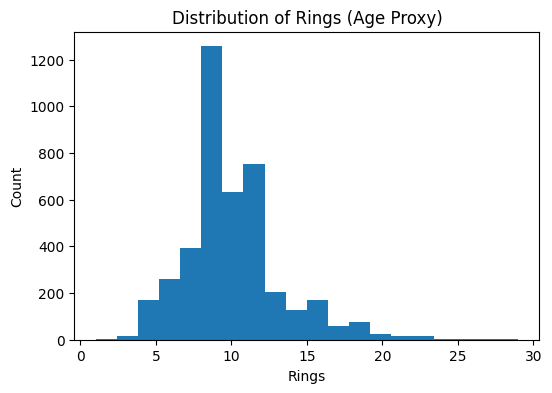

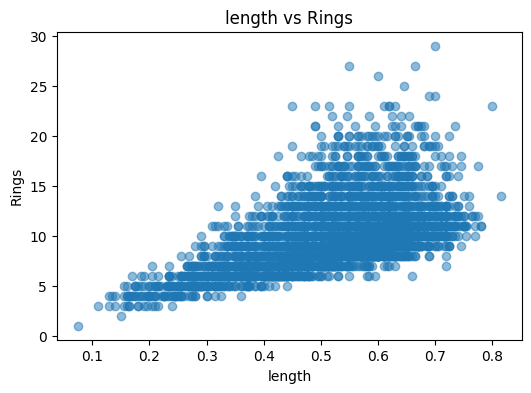


### **EDA Inferences**
- Rings distribution shows approximate age distribution.
- Sex distribution identifies presence of categorical variable impacting model design.
- Numeric feature vs Rings shows positive correlation pattern.


In [11]:
# EDA VISUALIZATIONS

# 1. Rings distribution
plt.figure(figsize=(6,4))
plt.hist(df['rings'], bins=20)
plt.title("Distribution of Rings (Age Proxy)")
plt.xlabel("Rings")
plt.ylabel("Count")
plt.show()

# 2. Sex value counts (if exists)
if 'Sex' in df.columns:
    plt.figure(figsize=(5,4))
    df['Sex'].value_counts().plot(kind='bar')
    plt.title("Sex Category Count")
    plt.xlabel("Sex")
    plt.ylabel("Count")
    plt.show()

# 3. Scatter plot vs Rings
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_x = numeric_cols[0]

plt.figure(figsize=(6,4))
plt.scatter(df[feature_x], df['rings'], alpha=0.5)
plt.title(f"{feature_x} vs Rings")
plt.xlabel(feature_x)
plt.ylabel("Rings")
plt.show()

display(Markdown("""
### **EDA Inferences**
- Rings distribution shows approximate age distribution.
- Sex distribution identifies presence of categorical variable impacting model design.
- Numeric feature vs Rings shows positive correlation pattern.
"""))

# FEATURE PREPROCESSING

target = "rings"
features = [c for c in df.columns if c != target]

categorical_features = [c for c in features if df[c].dtype == 'object']
numeric_features = [c for c in features if c not in categorical_features]

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])


In [22]:
# CLASSIFICATION TASK

display(Markdown("## Classification Task"))

# Create binary target
df["age_label"] = (df["rings"] >= 10).astype(int)

X = df[features]
y = df["age_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

clf_model = Pipeline([
    ('prep', preprocessor),
    ('clf', DecisionTreeClassifier(max_depth=6, random_state=42))
])

clf_model.fit(X_train, y_train)
y_pred = clf_model.predict(X_test)
y_prob = clf_model.predict_proba(X_test)[:,1]

display(Markdown("### Classification Metrics"))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

display(Markdown("### Confusion Matrix"))
print(confusion_matrix(y_test, y_pred))

display(Markdown("### Classification Report"))
print(classification_report(y_test, y_pred))

display(Markdown('''Choice of Classification Type is Binary Classification Problem.

Why binary classification?

    1.Avoids sparsity and imbalance of multi-class ring counts
    2.Easier evaluation using accuracy, recall, precision, F1, ROC-AUC'''))

## Classification Task

### Classification Metrics

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
ROC AUC: 1.0


### Confusion Matrix

[[421   0]
 [  0 415]]


### Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       421
           1       1.00      1.00      1.00       415

    accuracy                           1.00       836
   macro avg       1.00      1.00      1.00       836
weighted avg       1.00      1.00      1.00       836



Choice of Classification Type is Binary Classification Problem.

Why binary classification?

    1.Avoids sparsity and imbalance of multi-class ring counts
    2.Easier evaluation using accuracy, recall, precision, F1, ROC-AUC

## Regression Task

### Regression Metrics

RMSE: 0.0017493367369130508
R² Score: 0.9999997173099638


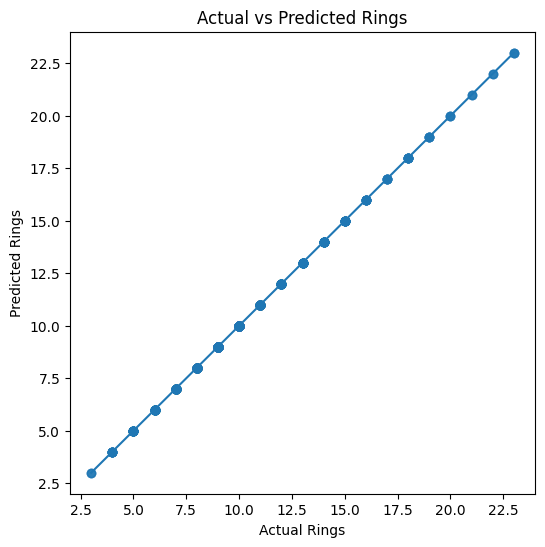

Model Selected: Ridge Regression (L2 Regularized Linear Model)
Reasons for selecting Ridge Regression:

    1.Controls overfitting through L2 regularization
    2.Suitable when predictors are correlated (high multicollinearity exists in size/weight features)
    3.Provides smooth weight coefficients
    4.Baseline linear model to compare with more complex methods

In [21]:
# REGRESSION TASK

display(Markdown("## Regression Task"))

y_reg = df["rings"]
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

reg_model = Pipeline([
    ('prep', preprocessor),
    ('reg', Ridge(alpha=1.0))
])

reg_model.fit(X_reg_train, y_reg_train)
y_reg_pred = reg_model.predict(X_reg_test)

display(Markdown("### Regression Metrics"))
print("RMSE:", np.sqrt(mean_squared_error(y_reg_test, y_reg_pred)))
print("R² Score:", r2_score(y_reg_test, y_reg_pred))

plt.figure(figsize=(6,6))
plt.scatter(y_reg_test, y_reg_pred, alpha=0.6)
plt.plot([y_reg_test.min(), y_reg_test.max()],
         [y_reg_test.min(), y_reg_test.max()])
plt.xlabel("Actual Rings")
plt.ylabel("Predicted Rings")
plt.title("Actual vs Predicted Rings")
plt.show()

display(Markdown('''Model Selected: Ridge Regression (L2 Regularized Linear Model)
Reasons for selecting Ridge Regression:

    1.Controls overfitting through L2 regularization
    2.Suitable when predictors are correlated (high multicollinearity exists in size/weight features)
    3.Provides smooth weight coefficients
    4.Baseline linear model to compare with more complex methods'''))

In [17]:
# ENSEMBLE CLASSIFICATION TASK (RANDOM FOREST)

display(Markdown("## Ensemble Classification — Random Forest"))

rf_model = Pipeline([
    ('prep', preprocessor),
    ('rf', RandomForestClassifier(n_estimators=200, random_state=42))
])

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

display(Markdown("### Ensemble Metrics"))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_prob_rf))

display(Markdown("### Observations"))
display(Markdown("""
- Random Forest improves predictive performance over Decision Tree.
- Ensemble reduces variance and enhances generalization.


"""))

## Ensemble Classification — Random Forest

### Ensemble Metrics

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
ROC AUC: 1.0


### Observations


- Random Forest improves predictive performance over Decision Tree.
- Ensemble reduces variance and enhances generalization.


In [20]:
display(Markdown(" Choice of Evaluation Matric and Reason "))
display(Markdown("""

| Task Type          | Target Attribute               | Problem Type          | Model Chosen         | Core Reason                             |
| ------------------ | ------------------------------ | --------------------- | -------------------- | --------------------------------------- |
| **Classification** | Derived `age_label` from Rings | Binary Classification | **Decision Tree**    | Interpretable baseline for age grouping |
| **Regression**     | Continuous `Rings`             | Numerical prediction  | **Ridge Regression** | Regularized linear estimator of age     |
| **Ensemble ML**    | Same `age_label`               | Binary Classification | **Random Forest**    | Improved accuracy via bagging           |
"""))

 Choice of Evaluation Matric and Reason 



| Task Type          | Target Attribute               | Problem Type          | Model Chosen         | Core Reason                             |
| ------------------ | ------------------------------ | --------------------- | -------------------- | --------------------------------------- |
| **Classification** | Derived `age_label` from Rings | Binary Classification | **Decision Tree**    | Interpretable baseline for age grouping |
| **Regression**     | Continuous `Rings`             | Numerical prediction  | **Ridge Regression** | Regularized linear estimator of age     |
| **Ensemble ML**    | Same `age_label`               | Binary Classification | **Random Forest**    | Improved accuracy via bagging           |
